## Time to get you hands dirty!  Position of a star

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*

You measure the position of a star $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`) 
- Compare it with the MLE estimator derived above

### Part 2

Check the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees) 

### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

# import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

# code

In [2]:
# ho_gauss = np.random.normal(loc = 1, scale = 0.2, size = 10000)
#credo di aver capito? 10 punti distribuiti in modo gaussiano
ho_gauss = np.random.normal(loc = 1, scale = 0.2, size = 10)

## 10

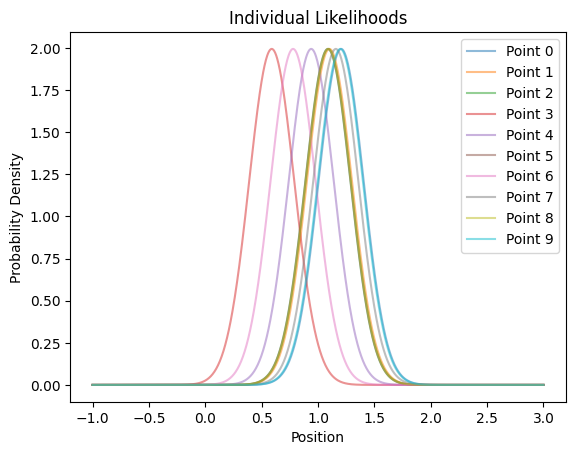

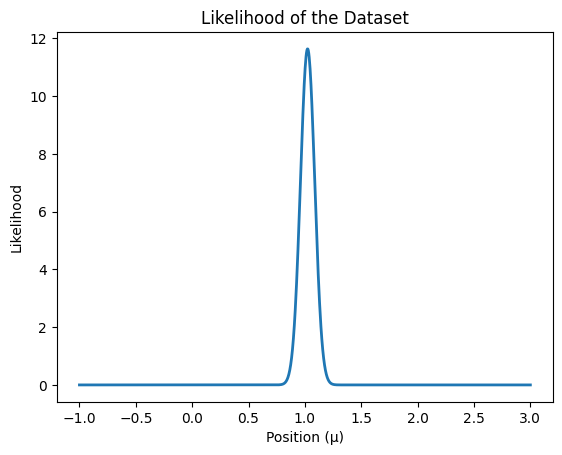

In [3]:
# Create likelihood distributions for each measurement
x = np.linspace(-1, 3, 1000)  # x -plot
sigma = 0.2

# compute individual likelihoods for each data point
likelihoods = np.array([scipy.stats.norm.pdf(x, loc=point, scale=sigma) for point in ho_gauss])

# Plot individual likelihoods
for i, likelihood in enumerate(likelihoods):
    plt.plot(x, likelihood, alpha=0.5, label=f'Point {i}')

plt.xlabel('Position')
plt.ylabel('Probability Density')
plt.title('Individual Likelihoods')
plt.legend()
plt.show()

# Calculate the likelihood of the dataset (product of individual likelihoods)
likelihood_product = np.prod(likelihoods, axis=0)

# Plot the product (overall likelihood)
plt.plot(x, likelihood_product, linewidth=2)
plt.xlabel('Position (μ)')
plt.ylabel('Likelihood')
plt.title('Likelihood of the Dataset')
plt.show()


## 100

In [4]:
# trovo il max con argsort

indices = np.argsort(likelihood_product)
max_index = indices[len(indices) - 1]
x_max_sorted = x[max_index]
print( "most probable mu by sorted the total likelihood: ", x_max_sorted)
#per gaussian data:
# \sum_{i=1}^N \frac{(x_i - \hat \mu)}{\sigma^2} = 0, ma per sigma == homoscedastic, \hat mu si riduce = 1/N \sum{x_i} = mean
print("most probable mu analitically: ", np.mean(ho_gauss))
distance10 = np.mean(ho_gauss) - x_max_sorted
print("distance between values:", distance10)

most probable mu by sorted the total likelihood:  1.0220220220220222
most probable mu analitically:  1.0238407085651753
distance between values: 0.0018186865431530919


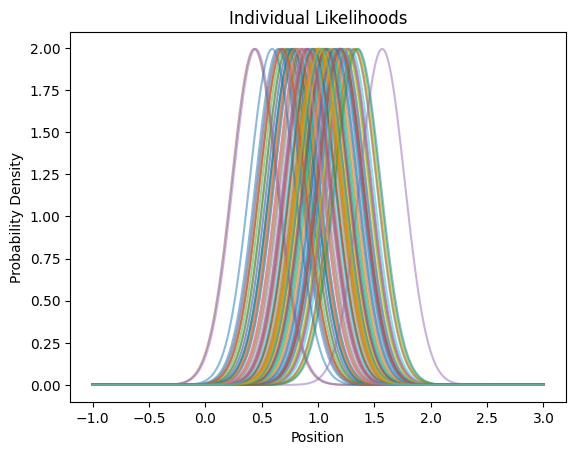

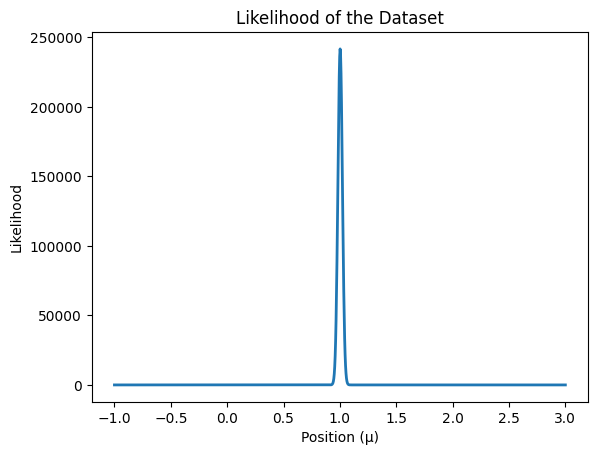

most probable mu by sorted the total likelihood:  1.0020020020020022
most probable mu analitically:  1.0022685689042778
distance between values: 0.0002665669022756667


In [5]:
#this is for 10 data, now i try with 100
ho_gauss = np.random.normal(loc = 1, scale = 0.2, size = 100)
# Create likelihood distributions for each measurement
x = np.linspace(-1, 3, 1000)  # x -plot
sigma = 0.2

# compute individual likelihoods for each data point
likelihoods = np.array([scipy.stats.norm.pdf(x, loc=point, scale=sigma) for point in ho_gauss])

# Plot individual likelihoods
for i, likelihood in enumerate(likelihoods):
    plt.plot(x, likelihood, alpha=0.5, label=f'Point {i}')

plt.xlabel('Position')
plt.ylabel('Probability Density')
plt.title('Individual Likelihoods')
# plt.legend()
plt.show()

# Calculate the likelihood of the dataset (product of individual likelihoods)
likelihood_product = np.prod(likelihoods, axis=0)

# Plot the product (overall likelihood)
plt.plot(x, likelihood_product, linewidth=2)
plt.xlabel('Position (μ)')
plt.ylabel('Likelihood')
plt.title('Likelihood of the Dataset')
plt.show()

# trovo il max con argsort

indices = np.argsort(likelihood_product)
max_index = indices[len(indices) - 1]
x_max_sorted = x[max_index]
print( "most probable mu by sorted the total likelihood: ", x_max_sorted)
#per gaussian data:
# \sum_{i=1}^N \frac{(x_i - \hat \mu)}{\sigma^2} = 0, ma per sigma == homoscedastic, \hat mu si riduce = 1/N \sum{x_i} = mean
print("most probable mu analitically: ", np.mean(ho_gauss))
distance100 = np.mean(ho_gauss) - x_max_sorted
print("distance between values:", distance100)


In [6]:
print("distance for 10 points: ", distance10, "distance for 100 points: ", distance100)

distance for 10 points:  0.0018186865431530919 distance for 100 points:  0.0002665669022756667


## 1000

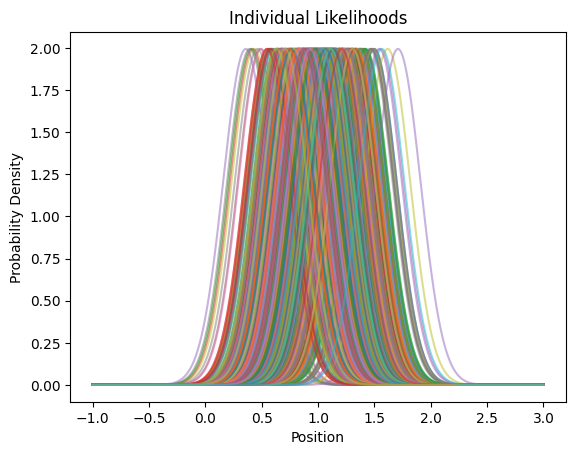

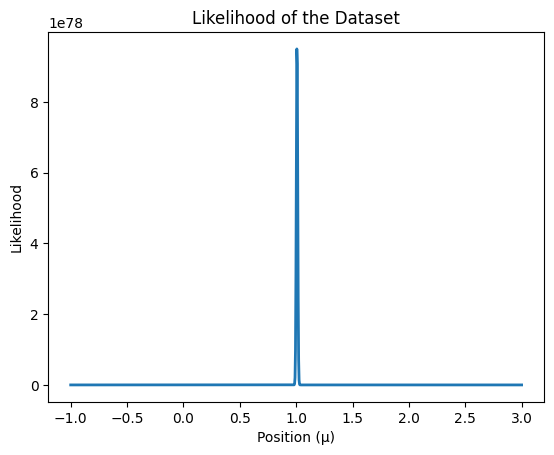

most probable mu by sorted the total likelihood:  1.006006006006006
most probable mu analitically:  1.0075521631960653
distance between values: 0.0015461571900592386


In [7]:
#this is for 10 data, now i try with 1000
ho_gauss = np.random.normal(loc = 1, scale = 0.2, size = 1000)
# Create likelihood distributions for each measurement
x = np.linspace(-1, 3, 1000)  # x -plot
sigma = 0.2

# compute individual likelihoods for each data point
likelihoods = np.array([scipy.stats.norm.pdf(x, loc=point, scale=sigma) for point in ho_gauss])

# Plot individual likelihoods
for i, likelihood in enumerate(likelihoods):
    plt.plot(x, likelihood, alpha=0.5, label=f'Point {i}')

plt.xlabel('Position')
plt.ylabel('Probability Density')
plt.title('Individual Likelihoods')
# plt.legend()
plt.show()

# Calculate the likelihood of the dataset (product of individual likelihoods)
likelihood_product = np.prod(likelihoods, axis=0)

# Plot the product (overall likelihood)
plt.plot(x, likelihood_product, linewidth=2)
plt.xlabel('Position (μ)')
plt.ylabel('Likelihood')
plt.title('Likelihood of the Dataset')
plt.show()

# trovo il max con argsort

indices = np.argsort(likelihood_product)
max_index = indices[len(indices) - 1]
x_max_sorted = x[max_index]
print( "most probable mu by sorted the total likelihood: ", x_max_sorted)
#per gaussian data:
# \sum_{i=1}^N \frac{(x_i - \hat \mu)}{\sigma^2} = 0, ma per sigma == homoscedastic, \hat mu si riduce = 1/N \sum{x_i} = mean
print("most probable mu analitically: ", np.mean(ho_gauss))
distance1000 = np.mean(ho_gauss) - x_max_sorted
print("distance between values:", distance1000)


## part 2

In [8]:
derivative = np.diff(np.log10(likelihood_product), 2)


error = 1/ np.sqrt(- ( derivative[max_index] / distance1000 **2))
print("error calculated with Fisher information: ",error)
print("error calculated from the exact derivative:", sigma/np.sqrt(1000))


error calculated with Fisher information:  0.0037059280327373947
error calculated from the exact derivative: 0.006324555320336759


/tmp/ipykernel_8806/3197004788.py:1: RuntimeWarning: divide by zero encountered in log10
  derivative = np.diff(np.log10(likelihood_product), 2)
/home/matti/uni/lab/myenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1518: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


the fisher information returns a smaller value than the one calculated from the derivative method. maybe the derivative method is affected by errors in the np.diff() method that is a discrete differenciation function

## part 3

In [18]:

#scale da dare nel caso eteroscedastic: np.random.normal(0.2, 0.05, size = size)
def func(loc, scale, size=1000, plot=True):
    if scale.ndim == 0:
        gauss = np.random.normal(loc = loc, scale = scale, size = size)
    if scale.ndim != 0:
        # loc = devo rendere loc della stessa dimensione di scale
        loc_array = np.full(len(scale), loc)
        gauss = np.random.normal(loc = loc_array, scale = scale, size = size)
        
    x = np.linspace(-1, 3, size)  # x -plot
        # compute individual likelihoods for each data point
    likelihoods = np.array([scipy.stats.norm.pdf(x, loc=point, scale=scale_i) 
                            for point, scale_i in zip(gauss, scale)])
        # Calculate the likelihood of the dataset (product of individual likelihoods)
    likelihood_product = np.prod(likelihoods, axis=0)

# Plot individual likelihoods
    if (plot == True):
        for i, likelihood in enumerate(likelihoods):
            plt.plot(x, likelihood, alpha=0.5, label=f'Point {i}')

        plt.xlabel('Position')
        plt.ylabel('Probability Density')
        plt.title('Individual Likelihoods')
        plt.show()

            #plot the likelihood of all the dataset
        plt.plot(x, likelihood_product, linewidth=2)
        plt.xlabel('Position (mu)')
        plt.ylabel('Likelihood')
        plt.title('Likelihood of the Dataset')
        plt.show()

        # find the max with argsort
    indices = np.argsort(likelihood_product)   
    max_index = indices[len(indices) - 1]
    x_max_sorted = x[max_index]
    print( "most probable mu by sorted the total likelihood: ", x_max_sorted)
        #per gaussian data:
        # \sum_{i=1}^N \frac{(x_i - \hat \mu)}{\scale^2} = 0, ma per scale == homoscedastic, \hat mu si riduce = 1/N \sum{x_i} = mean
    if (scale.ndim == 0):
        print("most probable mu analitically (mean of normal distributed values): ", np.mean(gauss))
        distance = np.mean(gauss) - x_max_sorted
        print("distance between values:", distance)
        error = scale / np.sqrt(size)
    else:
        mu_hat = np.sum( gauss / scale **2) / np.sum( 1/ scale **2) 
        print('most probable mu analitically (sum(x_i  / scale**2) / sum(1/ scale**2)): ', mu_hat)
        distance = mu_hat - x_max_sorted
        print("distance between values:", distance)
        error = np.sum( 1 / scale **2)**-(1/2) 
    derivative = np.diff(np.log10(likelihood_product), 2)
    fisher_error = 1/ np.sqrt(- ( derivative[max_index] / distance **2))
    print("fisher error:", fisher_error, "'analitic' error:", error)

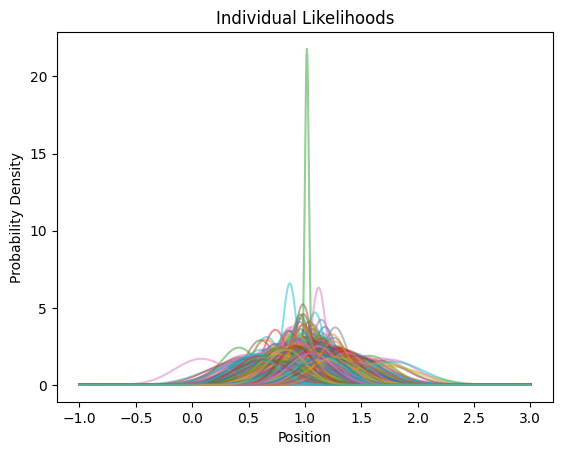

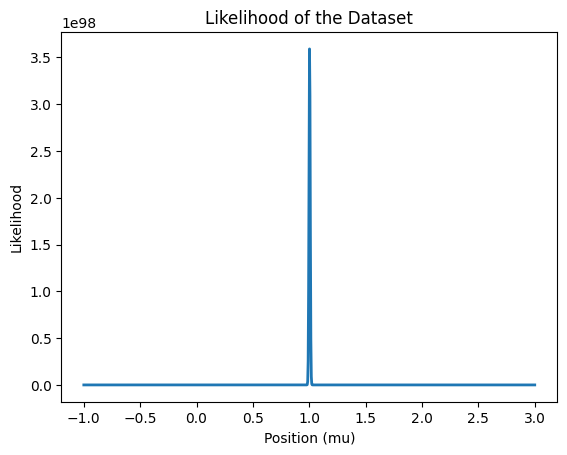

most probable mu by sorted the total likelihood:  1.0020020020020022
most probable mu analitically (sum(x_i  / scale**2) / sum(1/ scale**2)):  1.0028438009060776
distance between values: 0.0008417989040754303
fisher error: 0.0017793375996968664 'analitic' error: 0.005577462497443243


/tmp/ipykernel_8806/927340037.py:52: RuntimeWarning: divide by zero encountered in log10
  derivative = np.diff(np.log10(likelihood_product), 2)


In [19]:
size = 1000
func(1, np.random.normal(0.2, 0.05, size = size), size, plot = True)
